# KMeans Clustering: A Comprehensive Guide

## 1. Introduction

This notebook covers the step-by-step implementation of **KMeans Clustering** in Python.

### Concept Overview
An unsupervised partitioning algorithm that groups data points into K clusters centered around iteratively calculated centroids.

### Mathematical Formula
The core mathematical relationship or objective is defined as:
$$
J = \sum_{j=1}^K \sum_{\mathbf{x}_i \in S_j} \|\mathbf{x}_i - \boldsymbol{\mu}_j\|^2 \quad \text{(Minimize WCSS)}
$$

### Real-World Analogy
**Analogy:** Setting up K shipping hubs in a country to minimize delivery distance to all stores.

### Worked Example
**Worked Example:** Grouping shoppers by income and spending habits. We set K=3 hubs. KMeans iteratively assigns shoppers to nearest hubs, then shifts hubs to average coordinates, converging into 3 customer segments.

## 2. Import Libraries

We import the standard data science and machine learning libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Create Synthetic Dataset

We generate a realistic synthetic dataset to demonstrate the model's behavior and save it locally.

In [2]:
# Programmatic generation of 2D customer groups
from sklearn.datasets import make_blobs
np.random.seed(42)
X_raw, _ = make_blobs(n_samples=500, n_features=2, centers=3, cluster_std=1.2, random_state=42)
df = pd.DataFrame({
    'AnnualIncome': np.round(X_raw[:, 0] * 6 + 60, 2),
    'SpendingScore': np.round(X_raw[:, 1] * 8 + 50, 2)
})
df.to_csv('dataset.csv', index=False)

## 4. Load & Inspect Dataset

We load the dataset using pandas to inspect the shape, variables, and summary statistics.

In [3]:
df = pd.read_csv('dataset.csv')
print('Dataset Shape:', df.shape)
df.info()
print(df.describe())

Dataset Shape: (500, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   AnnualIncome   500 non-null    float64
 1   SpendingScore  500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB
       AnnualIncome  SpendingScore
count    500.000000     500.000000
mean      50.609580      61.412280
std       29.148333      52.475598
min        3.730000     -28.310000
25%       23.175000       3.367500
50%       45.370000      64.755000
75%       82.732500     115.875000
max      110.010000     159.100000


## 5. Data Cleaning

Audit for missing values and duplicates.

In [4]:
print('Null values:\n', df.isnull().sum())
print('Duplicate count:', df.duplicated().sum())

Null values:
 AnnualIncome     0
SpendingScore    0
dtype: int64
Duplicate count: 0


## 6. Exploratory Data Analysis (EDA)

We visualize the distributions and correlations of features.

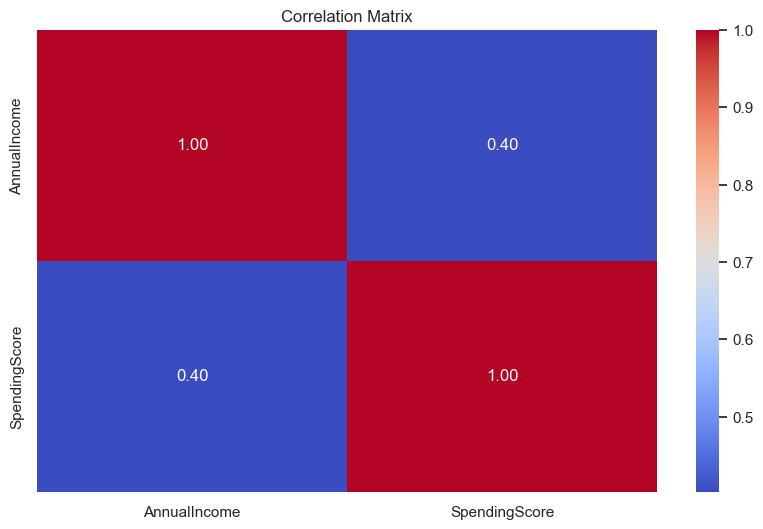

In [5]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 7. Feature Engineering & Scaling

Prepare the features and apply standardization if required.

In [6]:
X = df.copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Standard scaling applied.')

Standard scaling applied.


## 8. Train-Test Split

Divide training and testing sets.

In [7]:
# Unsupervised model - fitting directly on the scaled cohort
print('Skipping split step.')

Skipping split step.


## 9. Model Building

Instantiate and fit the model estimator.

In [8]:
model = KMeans(n_clusters=3, random_state=42, n_init=10)
model.fit(X_scaled)
print("KMeans centroids:\n", model.cluster_centers_)

KMeans centroids:
 [[ 1.27216649  0.07584983]
 [-1.08308982 -1.24500657]
 [-0.19556224  1.16170161]]


C:\Users\Acer\AppData\Roaming\Python\Python310\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Acer\AppData\Roaming\Python\Python310\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Program Files\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Program Files\Python310\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\Python310\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


## 10. Prediction & 11. Model Evaluation

Check metrics to evaluate model performance.

In [9]:
labels = model.labels_
# Guard: silhouette_score requires at least 2 distinct non-noise labels
unique_labels = set(labels)
if len(unique_labels - {-1}) >= 2:
    mask = labels != -1
    print('Silhouette Score:', silhouette_score(X_scaled[mask], labels[mask]))
else:
    print('Silhouette Score: N/A')

Silhouette Score: 0.8122095551254198


## 12. Visualizing Fit & Boundaries

Generate plots showing classification decision zones, regression lines, or clustering segments.

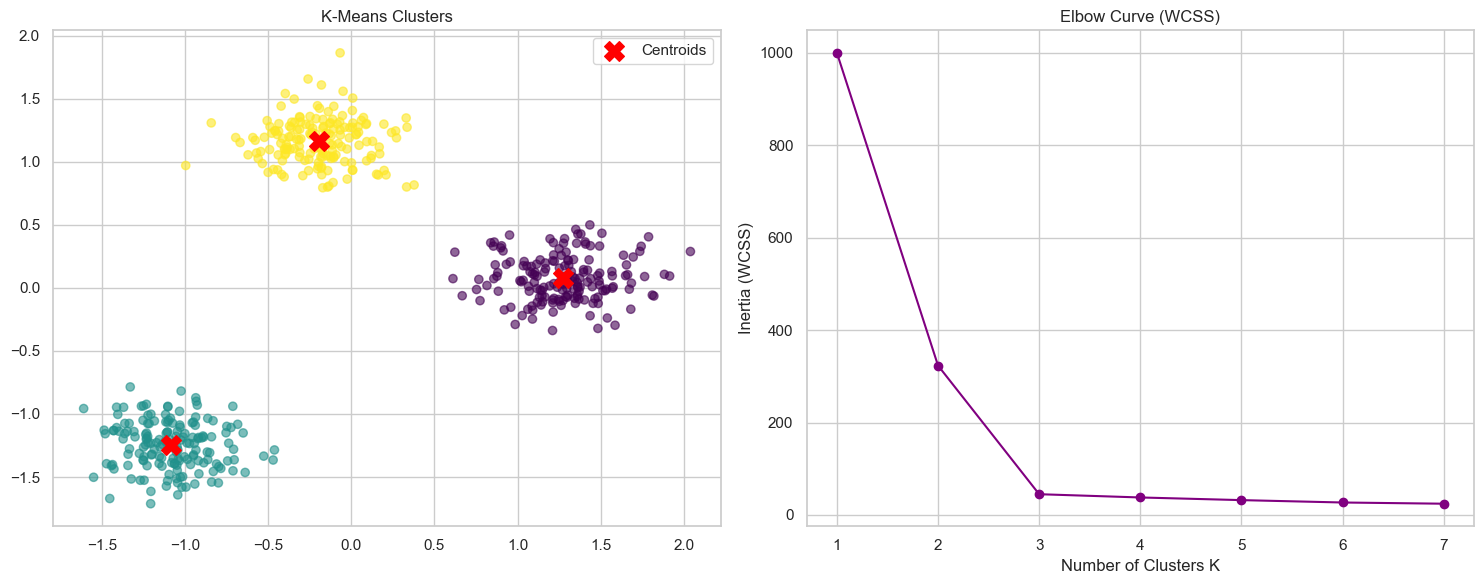

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# Plot 1: Clusters assignment
axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=model.labels_, cmap='viridis', alpha=0.6)
# Plot Centroids
centroids = model.cluster_centers_
axes[0].scatter(centroids[:, 0], centroids[:, 1], s=200, c='red', marker='X', label='Centroids')
axes[0].set_title("K-Means Clusters")
axes[0].legend()

# Plot 2: WCSS Elbow sweep (Inertia check)
wcss = []
K_range = range(1, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
axes[1].plot(K_range, wcss, marker='o', color='purple')
axes[1].set_title("Elbow Curve (WCSS)")
axes[1].set_xlabel("Number of Clusters K")
axes[1].set_ylabel("Inertia (WCSS)")
plt.tight_layout()
plt.show()

## 13. Save and Load Model

Serialize the model to disk via joblib.

In [11]:
joblib.dump(model, 'model.joblib')
loaded = joblib.load('model.joblib')
print('Loaded successfully!')

Loaded successfully!


## 14. Common Mistakes & Best Practices
- Forgetting to apply the fitted scaler to new evaluation data points, leading to prediction errors.
- Overfitting simple models with excessive features or polynomial terms.

## 15. Advantages
- Fast and easy to interpret baseline results.
- Requires minimal parameter tuning compared to deep neural networks.

## 16. Limitations
- Assumes linear or simple spatial patterns that do not always match real-world anomalies.
- Sensitive to noisy labels and extreme outliers.

## 17. Real-World Applications
- Predicting housing market price trends based on space features.
- Classifying credit card transactions as fraudulent vs benign.

## 18. Algorithm-Specific Interview Questions & Answers
**Q1: How does KMeans initialize and iterate?**

*A: 1. Randomly place K centroids. 2. Assign each point to the closest centroid. 3. Recompute centroids as mean coordinates of assigned points. Repeat steps 2 and 3 until convergence.*

**Q2: What is the Elbow Method?**

*A: Plotting WCSS (Inertia) against K values. The 'elbow' point is where WCSS decrease slows down dramatically, suggesting the optimal K.*

**Q3: What are the limitations of KMeans?**

*A: 1. Sensitive to initial centroid placement (can get stuck in local minima). 2. Requires specifying K in advance. 3. Struggles with non-spherical shapes and varying density clusters.*



## 19. Algorithm-Specific Viva Voce Questions & Answers
**Q1: What does 'inertia_' represent in scikit-learn?**

*A: The sum of squared distances of samples to their closest cluster centroid (Within-Cluster Sum of Squares).*

**Q2: What is the role of 'n_init'?**

*A: Specifies how many times KMeans runs with different centroid seeds, returning the run with the lowest WCSS.*

**Q3: Does KMeans require feature scaling?**

*A: Yes, because it uses Euclidean distance. Features with larger variance will dominate centroid assignments.*



## 20. Practice Exercises
1. **Hyperparameter sweep**: Modify model parameters (such as `max_depth` or neighbor count `K`) and plot the test metric variance curve.
2. **Manual metric calculation**: Compute precision and recall scores manually from the confusion matrix values and verify results using scikit-learn.
3. **Outlier test**: Add an extreme value row to the dataset, re-train, and record the boundary displacement shift.

## 21. Conclusion

In this notebook, we implemented the complete modeling cycle: generating datasets, performing scaling, training the model, evaluating predictions with multiple metrics, saving outputs, and studying typical interview Q&A profiles.